In [2]:
# ==============================
# 1. Imports & Configuration
# ==============================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["font.size"] = 11

np.random.seed(42)

In [6]:
df = pd.read_csv("final_clustered_data.csv")

metric_features = [
    'income',
    'frq',
    'rcn',
    'clothes',
    'kitchen',
    'small_appliances',
    'toys',
    'house_keeping',
    'per_net_purchase',
    'spent_online'
]

X = df[metric_features].to_numpy()

## PCA (Global Structure)

In [7]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

df['pca_1'] = X_pca[:,0]
df['pca_2'] = X_pca[:,1]

print("Variance explained:")
print("PC1:", round(pca.explained_variance_ratio_[0],3))
print("PC2:", round(pca.explained_variance_ratio_[1],3))
print("Total:", round(sum(pca.explained_variance_ratio_),3))

Variance explained:
PC1: 0.361
PC2: 0.233
Total: 0.594


In [8]:
df.head()

,Unnamed: 0,YoB,income,frq,rcn,mnt,clothes,kitchen,small_appliances,toys,...,oh_marital_status_Married,oh_marital_status_Single,oh_marital_status_Together,oh_marital_status_Whatever,oh_marital_status_Widow,behavior_labels,product_labels,labels,pca_1,pca_2
0,0,1946,0.756488,1.206285,0.050607,1402,-0.574129,-0.259907,1.229637,0.373941,...,0.0,0.0,1.0,0.0,0.0,3,1,1,1.109620,-1.854205
1,1,1936,1.564682,1.114566,-0.809510,1537,0.194413,-0.769611,0.752907,-0.383254,...,0.0,0.0,0.0,0.0,0.0,3,1,1,2.120869,-1.310421
2,2,1990,-1.512384,-0.811540,0.093613,44,-0.787614,1.524054,-0.359464,-0.761851,...,1.0,0.0,0.0,0.0,0.0,1,2,3,-2.688425,0.174833
3,3,1955,0.857835,0.564250,-0.752169,888,0.407897,0.377222,-0.756739,-0.130856,...,1.0,0.0,0.0,0.0,0.0,0,0,5,1.359238,-0.372397
4,4,1955,0.795370,1.022847,-0.522805,1138,0.365201,-0.259907,-0.041644,-0.383254,...,0.0,0.0,1.0,0.0,0.0,2,0,6,1.873599,-0.563652


In [9]:
labels = df['labels']

### PCA Visualization

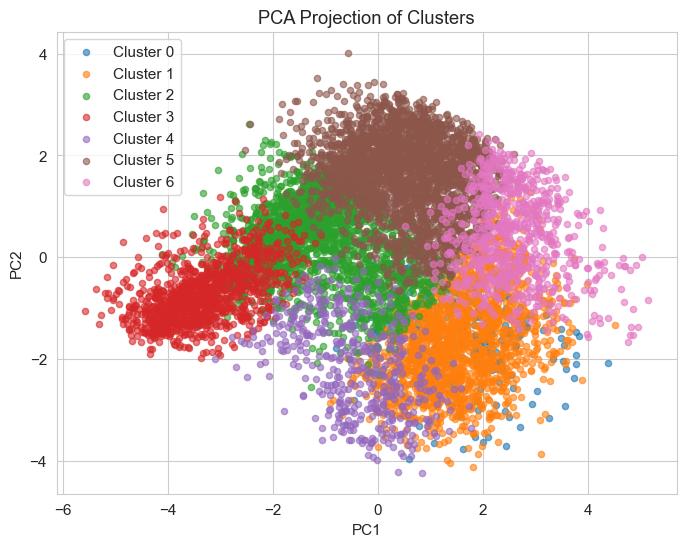

In [10]:
plt.figure(figsize=(8,6))

for cluster in sorted(labels.unique()):
    mask = labels == cluster
    plt.scatter(
        df.loc[mask, 'pca_1'],
        df.loc[mask, 'pca_2'],
        s=20,
        alpha=0.6,
        label=f'Cluster {cluster}'
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection of Clusters")
plt.legend()
plt.show()

## t-SNE - Local Structure


In [11]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init='pca'
)

X_tsne = tsne.fit_transform(df[metric_features])

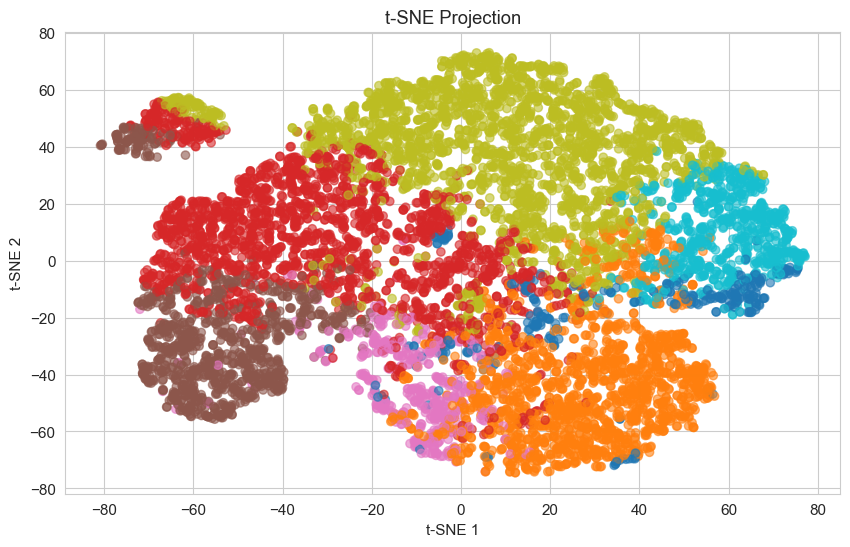

In [12]:
plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=df['labels'],
    cmap='tab10',
    alpha=0.6
)

plt.title("t-SNE Projection")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()